In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras import layers, models
from keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:
# Configuration
NUM_CLASSES = 10
IMAGE_SHAPE = (28, 28, 1)
BATCH_SIZE = 64
EPOCHS = 10
VALIDATION_SPLIT = 0.1
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def load_and_preprocess_mnist():
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
    
    # Reshaping 2D images to 3D tensors (28, 28, 1) to match Keras Conv2D input requirements
    X_train = X_train_raw.reshape(-1, *IMAGE_SHAPE).astype('float32') / 255.0
    X_test = X_test_raw.reshape(-1, *IMAGE_SHAPE).astype('float32') / 255.0
    
    # One-hot encoding categorical targets
    y_train = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
    y_test = tf.keras.utils.to_categorical(y_test_raw, NUM_CLASSES)
    
    return (X_train, y_train), (X_test, y_test), y_test_raw


def build_cnn_architecture():
    # 2D Conv layers capture spatial hierarchies (edges -> loops -> whole digits).
    # MaxPooling reduces spatial resolution to build translational invariance.
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMAGE_SHAPE),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        # 0.4 Dropout explicitly combats co-adaptation of features during training
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def evaluate_character_model(model, X_test, y_test_onehot, y_test_raw):
    test_loss, test_acc = model.evaluate(X_test, y_test_onehot, verbose=0)
    predictions = model.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)
    
    print(f"=== Handwritten Character Recognition Performance ===")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss:     {test_loss:.4f}\n")
    print(classification_report(y_test_raw, predicted_classes))
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        confusion_matrix(y_test_raw, predicted_classes),
        annot=True, fmt='d', cmap='Oranges'
    )
    plt.title('Handwritten Character Recognition - Confusion Matrix')
    plt.xlabel('Predicted Digit')
    plt.ylabel('Actual Digit')
    plt.tight_layout()
    plt.show()

Epoch 1/10


C:\Users\WIREKO ERIC\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9307 - loss: 0.2249 - val_accuracy: 0.9828 - val_loss: 0.0593
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9776 - loss: 0.0730 - val_accuracy: 0.9888 - val_loss: 0.0412
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9844 - loss: 0.0522 - val_accuracy: 0.9883 - val_loss: 0.0447
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9869 - loss: 0.0414 - val_accuracy: 0.9918 - val_loss: 0.0313
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9885 - loss: 0.0357 - val_accuracy: 0.9905 - val_loss: 0.0353
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9911 - loss: 0.0290 - val_accuracy: 0.9913 - val_loss: 0.0338
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9903 - val_loss: 0.0385
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9927 - loss: 0.0221 - val_accuracy: 0.98

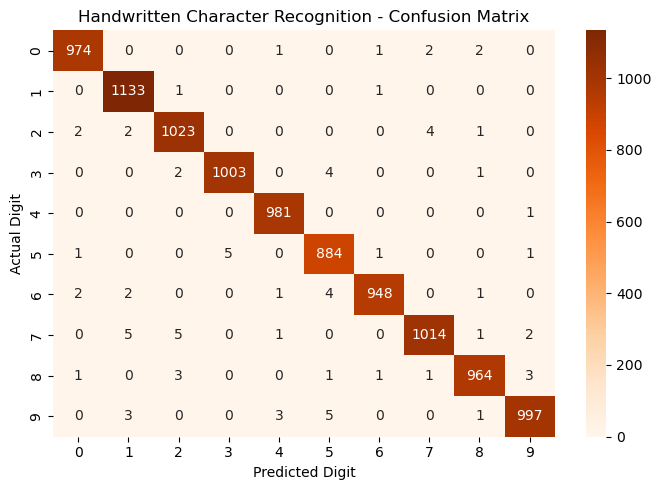

In [8]:
# --- Pipeline Execution ---
if __name__ == '__main__':
    (X_train, y_train), (X_test, y_test_onehot), y_test_raw = load_and_preprocess_mnist()
    
    cnn_model = build_cnn_architecture()
    
    history = cnn_model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        verbose=1
    )
    
    evaluate_character_model(cnn_model, X_test, y_test_onehot, y_test_raw)